In [50]:
import pandas as pd

df = pd.read_csv("water_potability.csv")
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [51]:
import matplotlib.pyplot as plt

print(df.shape)
print(df.dtypes)
display(df.describe())


(3276, 10)
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


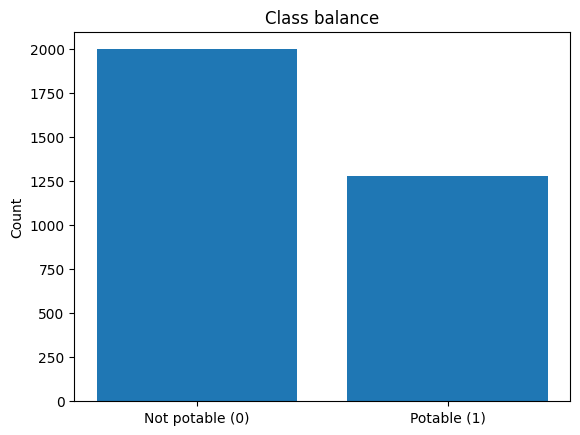

In [52]:
target_counts = df["Potability"].value_counts().sort_index()
plt.figure()
plt.bar(["Not potable (0)", "Potable (1)"], target_counts.values)
plt.title("Class balance")
plt.ylabel("Count")
plt.show()

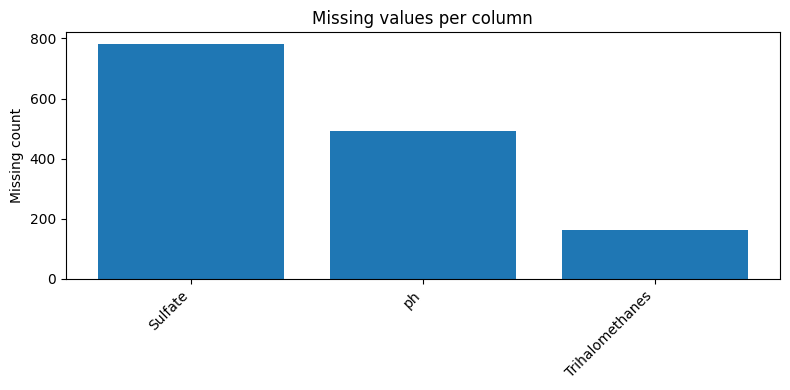

In [53]:
import numpy as np

na_count = df.isna().sum().sort_values(ascending=False)
na_count = na_count[na_count > 0]


plt.figure(figsize=(8, 4))
plt.bar(na_count.index, na_count.values)
plt.title("Missing values per column")
plt.ylabel("Missing count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


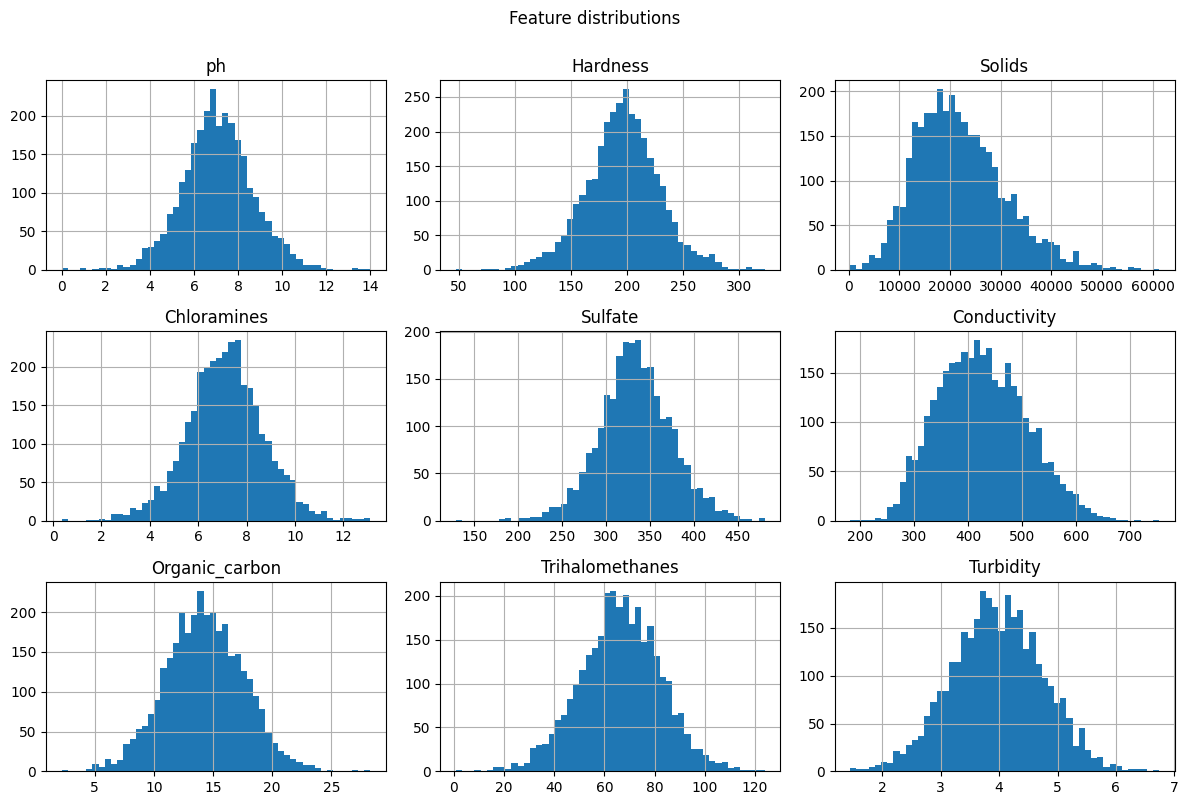

In [54]:
#histograms
features = [c for c in df.columns if c != "Potability"]

df[features].hist(bins=50, figsize=(12,8))
plt.suptitle("Feature distributions", y=1)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

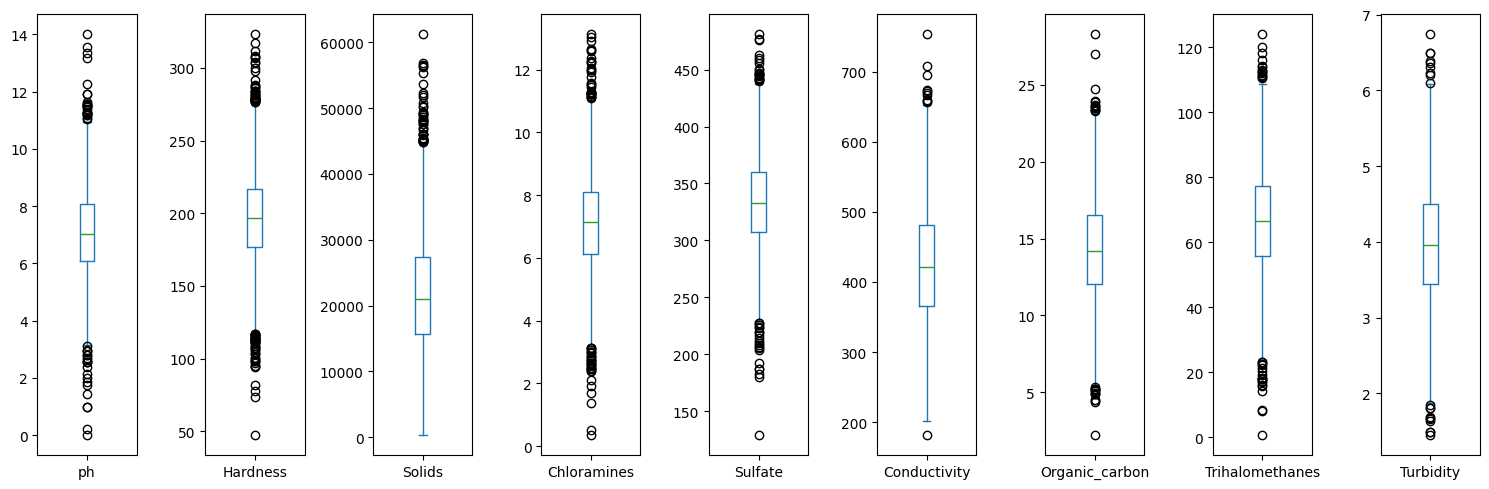

In [55]:
#boxplots

plt.figure(figsize=(12,8))
df[features].plot(kind='box', subplots=True, sharey=False, figsize=(15, 5))
plt.tight_layout()
plt.show()

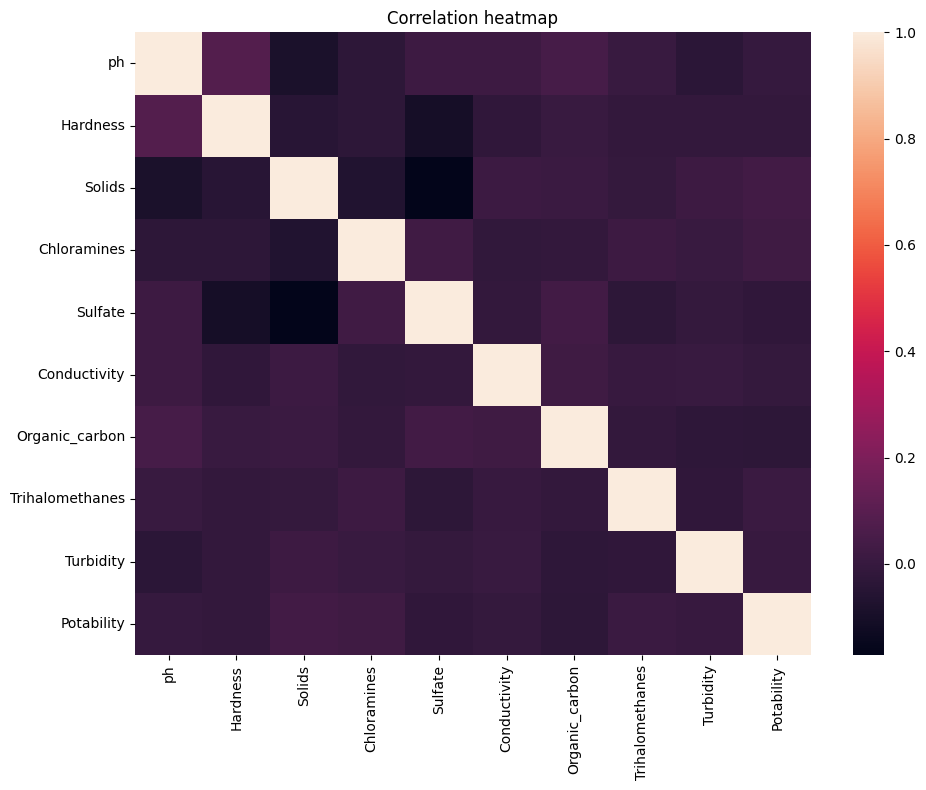

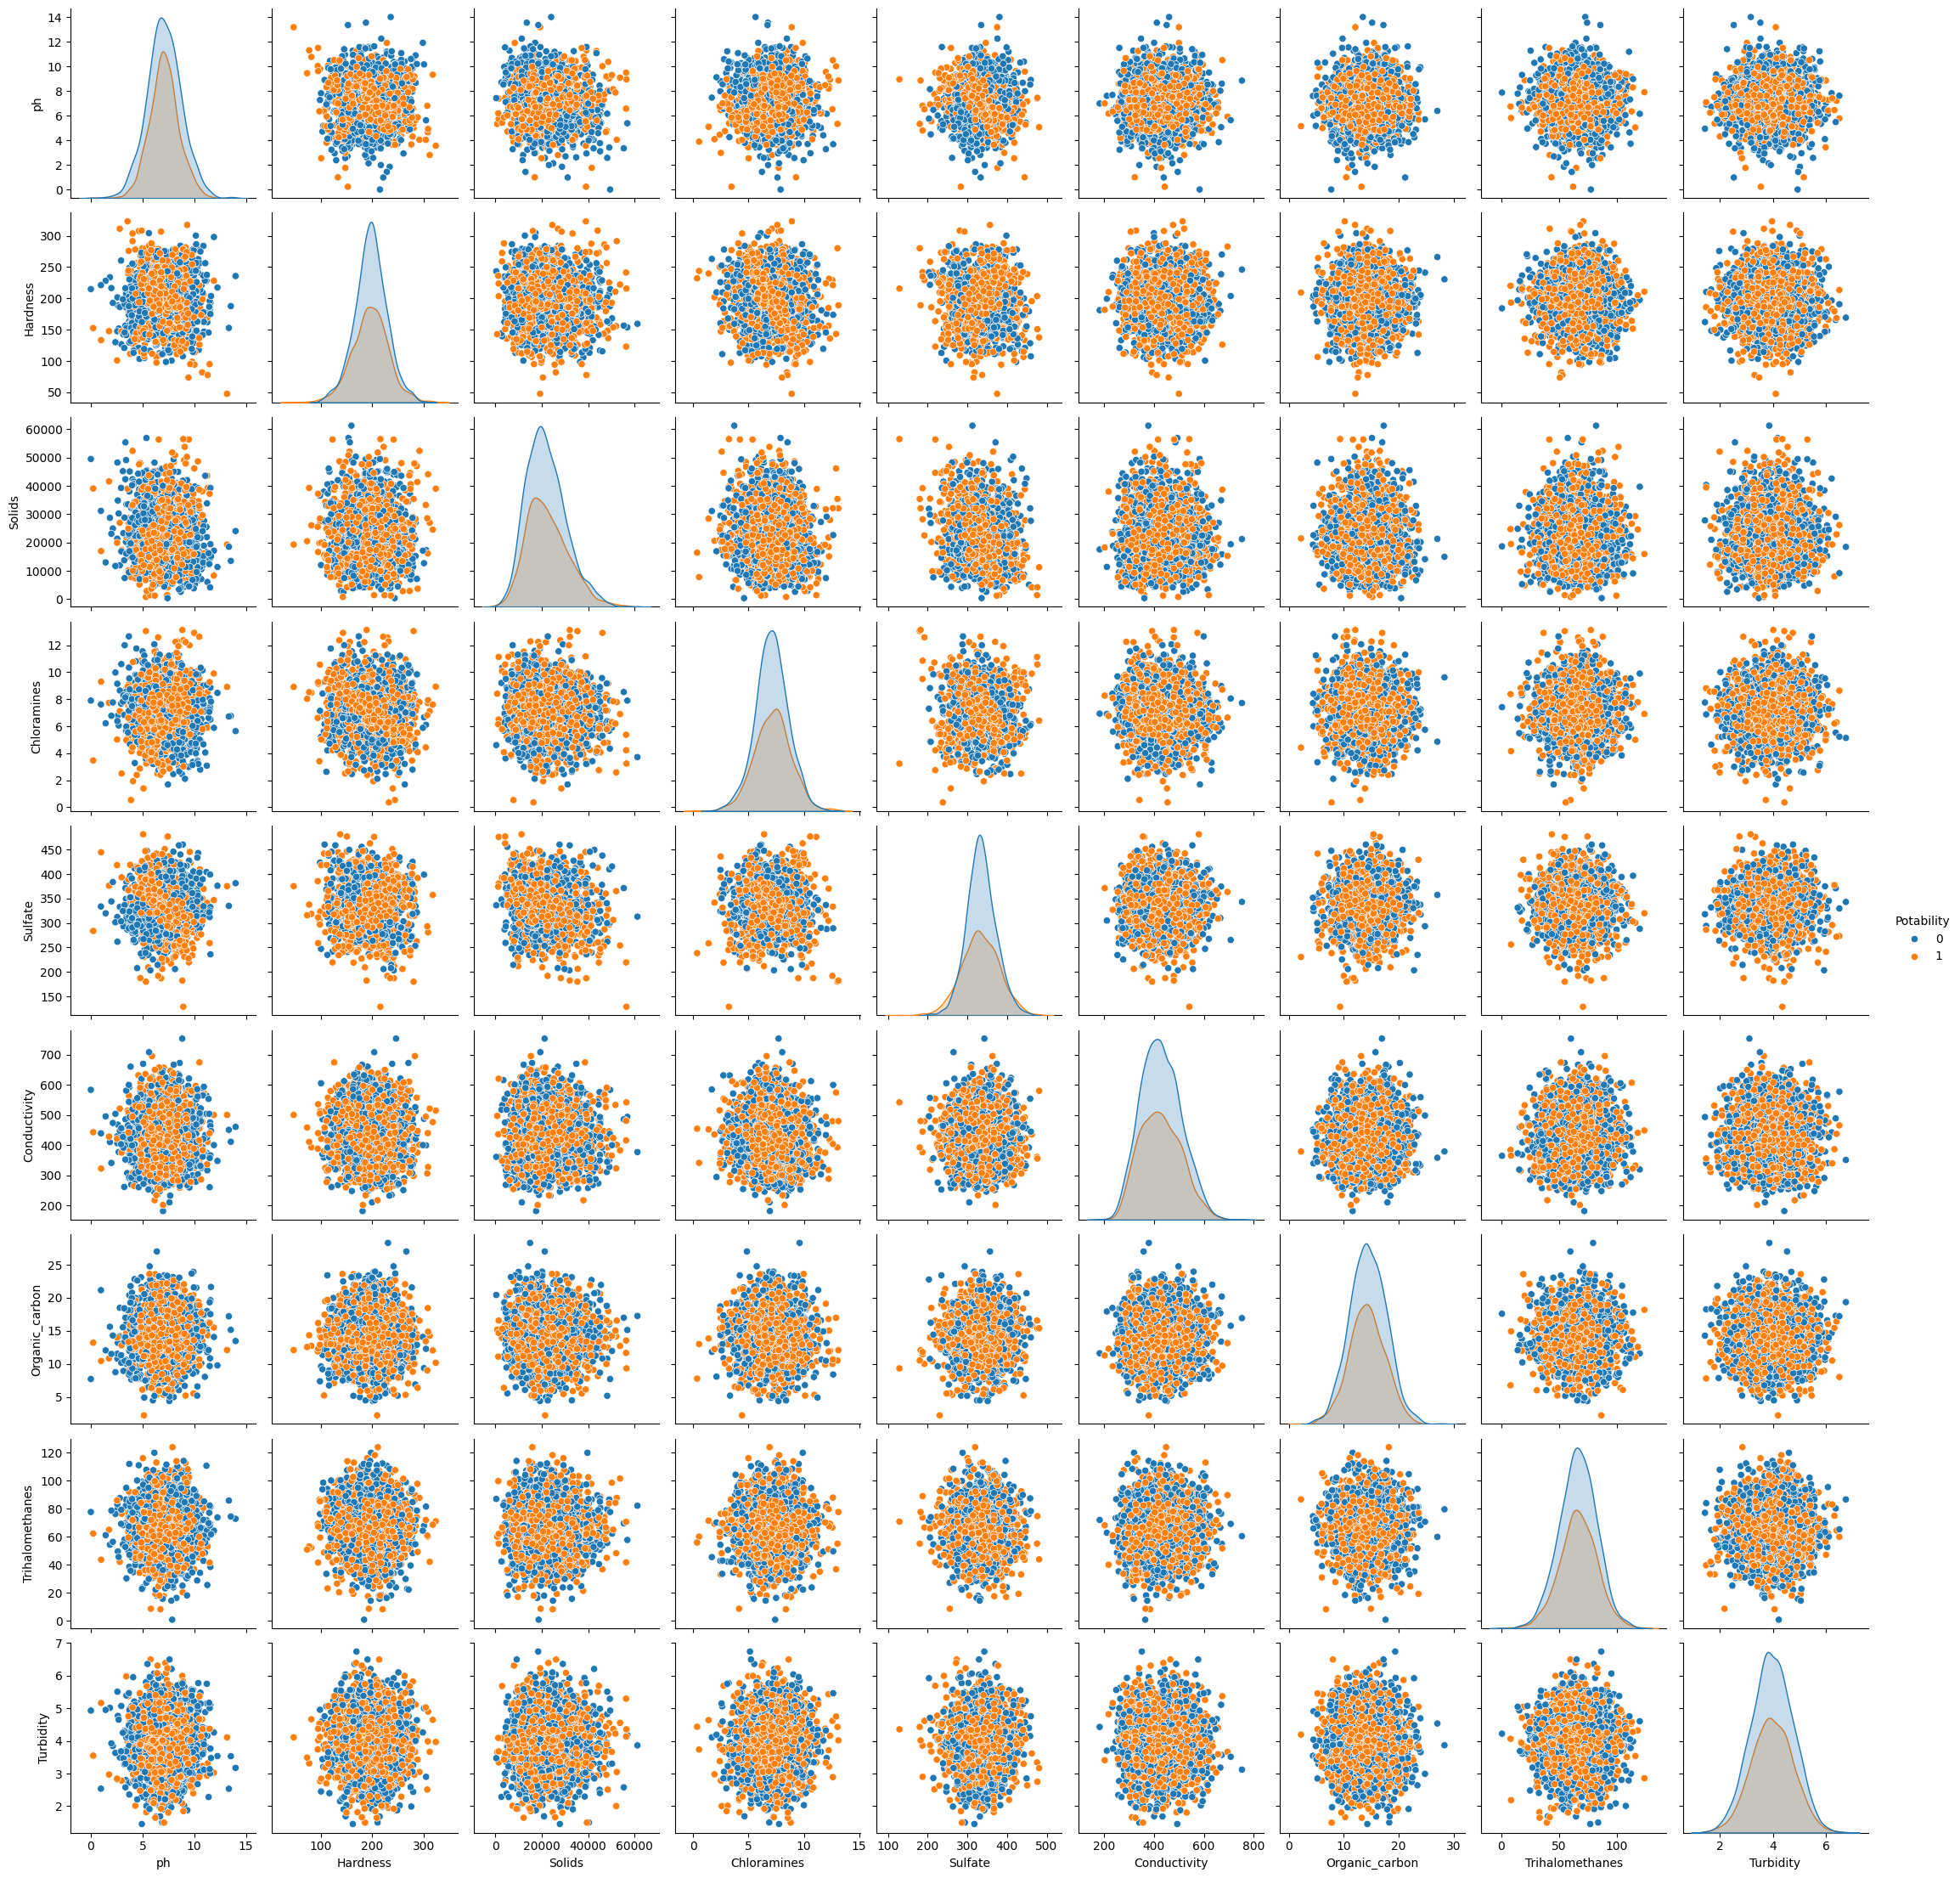

In [56]:
import seaborn as sb
plt.figure(figsize=(10, 8))
sb.heatmap(df[features + ["Potability"]].corr(), annot=False)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

import seaborn as sns

sns.pairplot(df, hue = 'Potability');

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

X = df.drop("Potability", axis=1)
y = df["Potability"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
     ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), num_features)
    ],
    remainder="drop"
)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier



models = {
    "LogReg": LogisticRegression(),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

pipelines = {
    name: Pipeline(steps=[("prep", preprocess), ("model", model)])
    for name, model in models.items()
}


In [59]:

from sklearn.metrics import classification_report




for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    print(f"\n=== {name} ===")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))



=== LogReg ===
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


=== SVM ===
              precision    recall  f1-score   support

           0       0.67      0.92      0.77       400
           1       0.68      0.29      0.40       256

    accuracy                           0.67       656
   macro avg       0.67      0.60      0.59       656
weighted avg       0.67      0.67      0.63       656



c:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       400
           1       0.63      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.65      0.60      0.59       656
weighted avg       0.65      0.66      0.63       656


=== GradientBoosting ===
              precision    recall  f1-score   support

           0       0.65      0.91      0.76       400
           1       0.64      0.25      0.36       256

    accuracy                           0.65       656
   macro avg       0.65      0.58      0.56       656
weighted avg       0.65      0.65      0.60       656


=== KNN ===
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       400
           1       0.51      0.32      0.40       256

    accuracy                           0.61       656
   macro avg       0.58      0.56      0.56       656
weighted avg 

In [60]:
# notes
#do cross validation
#keep to one split truought the whole exxperiment
#procentulano outliers do the math analysis (look it up)
#stratified split , keep the class raspodelu ocuvanu

#models tuned

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 12, 16],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    scoring="accuracy",   
    cv=5,
    n_jobs=-1
)

models = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "SVM": SVC(class_weight="balanced",C=1.0,gamma="scale", probability=True),
    "RandomForest": rf_search,
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance")
}

pipelines = {
    name: Pipeline(steps=[("prep", preprocess), ("model", model)])
    for name, model in models.items()
}



for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    print(f"\n=== {name} ===")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))


=== LogReg ===
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       400
           1       0.41      0.53      0.47       256

    accuracy                           0.52       656
   macro avg       0.52      0.53      0.52       656
weighted avg       0.55      0.52      0.53       656


=== SVM ===
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       400
           1       0.51      0.49      0.50       256

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.62      0.62       656


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.67      0.90      0.77       400
           1       0.67      0.31      0.42       256

    accuracy                           0.67       656
   macro avg       0.67      0.61      0.60       656
weighted avg       0.67

(3276, 10)


<Figure size 1200x800 with 0 Axes>

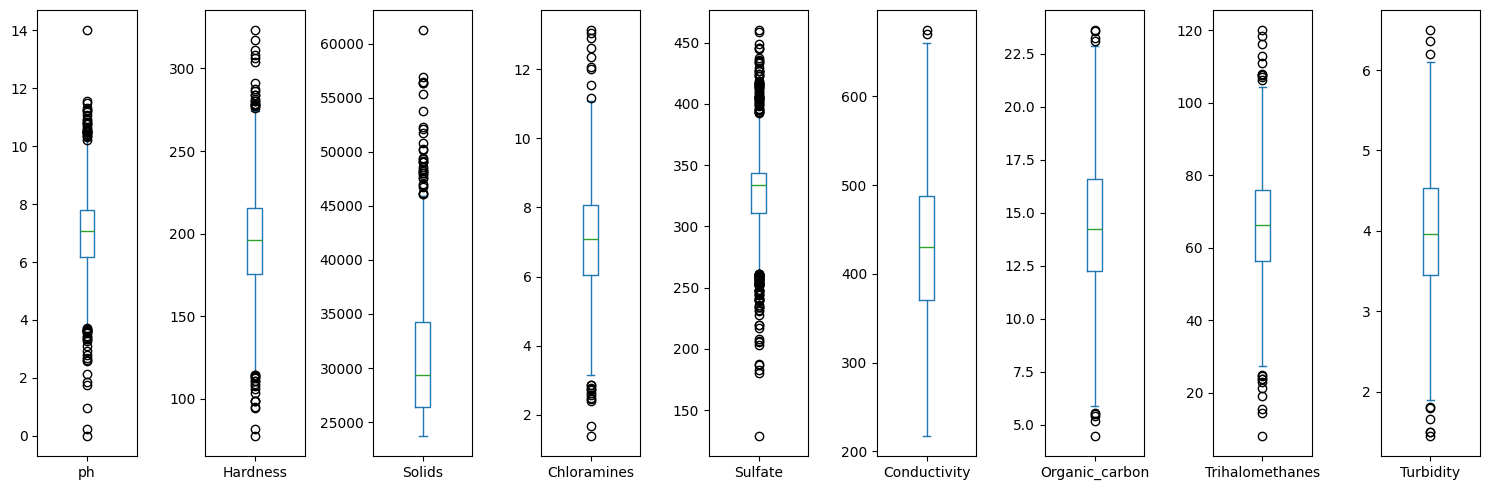


=== LogReg ===
Validation accuracy: 0.656
Validation report:
              precision    recall  f1-score   support

         0.0       0.66      0.89      0.75       149
         1.0       0.65      0.32      0.43       101

    accuracy                           0.66       250
   macro avg       0.65      0.60      0.59       250
weighted avg       0.66      0.66      0.62       250

Test report:
              precision    recall  f1-score   support

         0.0       0.65      0.88      0.74       149
         1.0       0.62      0.29      0.39       101

    accuracy                           0.64       250
   macro avg       0.63      0.58      0.57       250
weighted avg       0.63      0.64      0.60       250



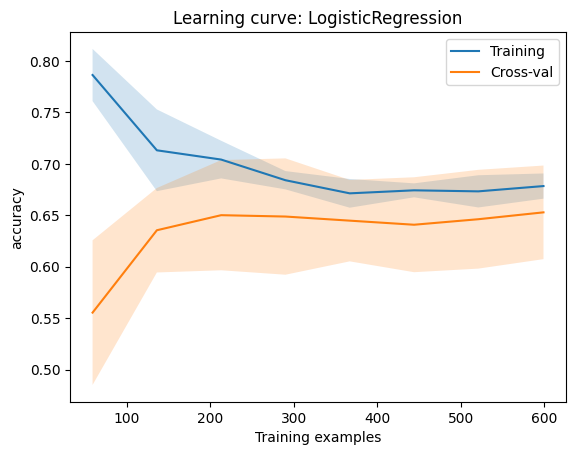


=== SVM ===
Validation accuracy: 0.688
Validation report:
              precision    recall  f1-score   support

         0.0       0.68      0.89      0.77       149
         1.0       0.70      0.40      0.51       101

    accuracy                           0.69       250
   macro avg       0.69      0.64      0.64       250
weighted avg       0.69      0.69      0.66       250

Test report:
              precision    recall  f1-score   support

         0.0       0.66      0.89      0.76       149
         1.0       0.67      0.34      0.45       101

    accuracy                           0.66       250
   macro avg       0.66      0.61      0.60       250
weighted avg       0.66      0.66      0.63       250



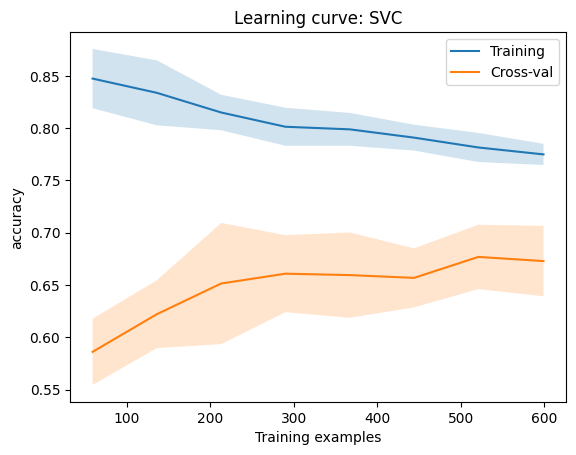


=== RandomForest ===
Validation accuracy: 0.676
Validation report:
              precision    recall  f1-score   support

         0.0       0.70      0.81      0.75       149
         1.0       0.63      0.48      0.54       101

    accuracy                           0.68       250
   macro avg       0.66      0.64      0.65       250
weighted avg       0.67      0.68      0.67       250

Test report:
              precision    recall  f1-score   support

         0.0       0.66      0.83      0.73       149
         1.0       0.59      0.38      0.46       101

    accuracy                           0.64       250
   macro avg       0.63      0.60      0.60       250
weighted avg       0.63      0.64      0.62       250



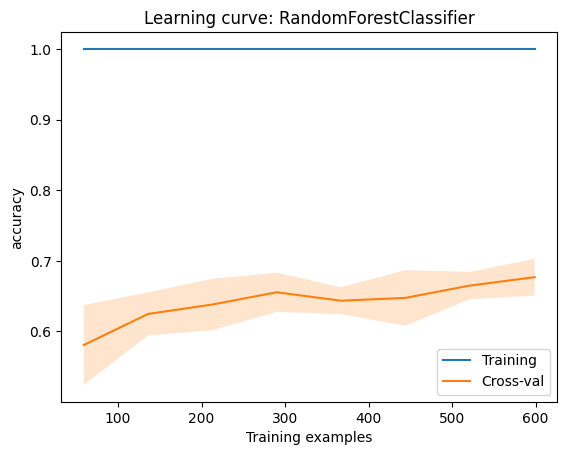


=== GradientBoosting ===
Validation accuracy: 0.640
Validation report:
              precision    recall  f1-score   support

         0.0       0.67      0.79      0.72       149
         1.0       0.58      0.42      0.48       101

    accuracy                           0.64       250
   macro avg       0.62      0.60      0.60       250
weighted avg       0.63      0.64      0.63       250

Test report:
              precision    recall  f1-score   support

         0.0       0.67      0.85      0.75       149
         1.0       0.63      0.38      0.47       101

    accuracy                           0.66       250
   macro avg       0.65      0.61      0.61       250
weighted avg       0.65      0.66      0.64       250



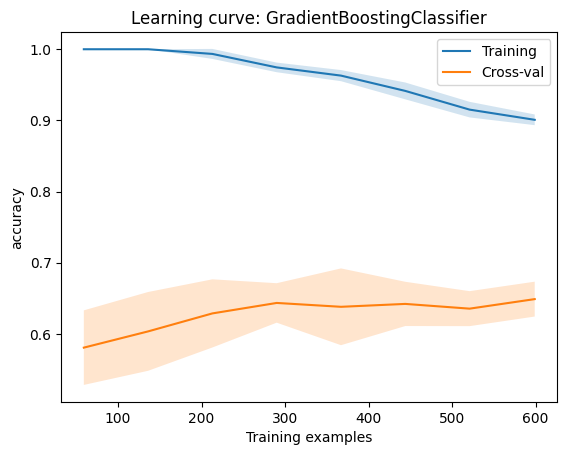


=== KNN ===
Validation accuracy: 0.616
Validation report:
              precision    recall  f1-score   support

         0.0       0.65      0.79      0.71       149
         1.0       0.54      0.37      0.44       101

    accuracy                           0.62       250
   macro avg       0.59      0.58      0.57       250
weighted avg       0.60      0.62      0.60       250

Test report:
              precision    recall  f1-score   support

         0.0       0.68      0.81      0.74       149
         1.0       0.61      0.44      0.51       101

    accuracy                           0.66       250
   macro avg       0.65      0.62      0.62       250
weighted avg       0.65      0.66      0.65       250



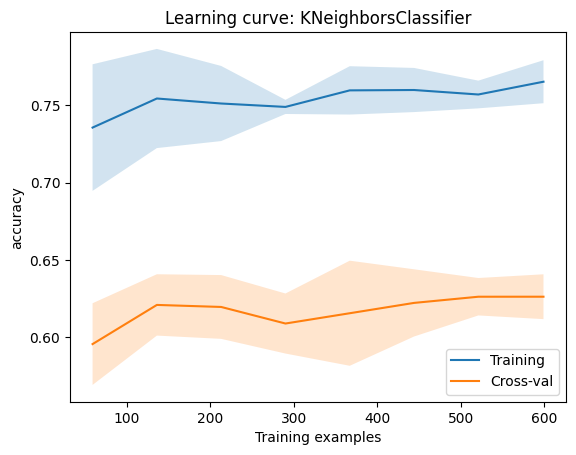


=== AdaBoost ===
Validation accuracy: 0.608
Validation report:
              precision    recall  f1-score   support

         0.0       0.63      0.82      0.71       149
         1.0       0.53      0.30      0.38       101

    accuracy                           0.61       250
   macro avg       0.58      0.56      0.55       250
weighted avg       0.59      0.61      0.58       250

Test report:
              precision    recall  f1-score   support

         0.0       0.65      0.83      0.73       149
         1.0       0.57      0.33      0.42       101

    accuracy                           0.63       250
   macro avg       0.61      0.58      0.57       250
weighted avg       0.61      0.63      0.60       250



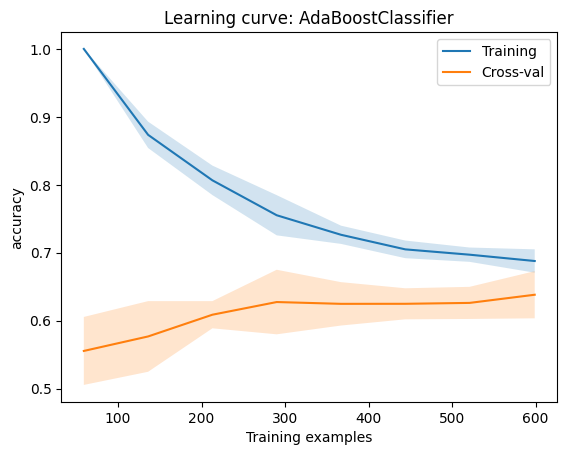


=== DecisionTree ===
Validation accuracy: 0.616
Validation report:
              precision    recall  f1-score   support

         0.0       0.68      0.66      0.67       149
         1.0       0.52      0.54      0.53       101

    accuracy                           0.62       250
   macro avg       0.60      0.60      0.60       250
weighted avg       0.62      0.62      0.62       250

Test report:
              precision    recall  f1-score   support

         0.0       0.67      0.68      0.68       149
         1.0       0.52      0.50      0.51       101

    accuracy                           0.61       250
   macro avg       0.60      0.59      0.60       250
weighted avg       0.61      0.61      0.61       250



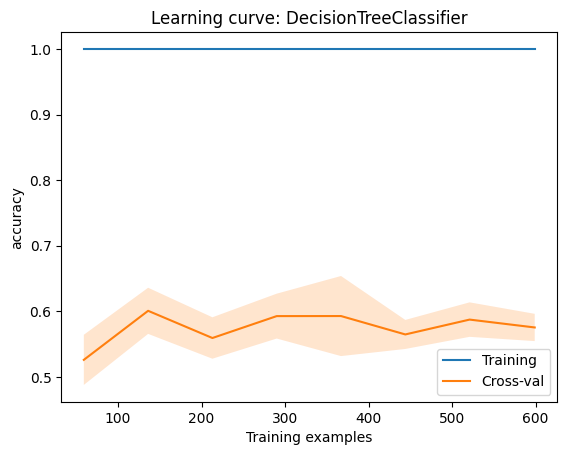

In [61]:
#Making a copy of the data and removing outliers to see if it improves the results
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

def plot_learning_curve(model, X, y, cv=5, scoring="accuracy"):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, label="Training")
    plt.plot(train_sizes, val_mean, label="Cross-val")
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.2)
    plt.title(f"Learning curve: {model.__class__.__name__}")
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend()
    plt.show()

# KMeansClustering - delete outlier
imputer = SimpleImputer(strategy='mean')
imputed_data =  pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns,
    index=df.index
)
#df.dropna(axis = 0, inplace = True)
kmeans = KMeans(n_clusters = 2)
kmeans.fit(imputed_data)
labels = kmeans.labels_
df2 = imputed_data[labels == 1]
df2.reset_index(inplace = True)
print(df.shape)

plt.figure(figsize=(12,8))
df2[features].plot(kind='box', subplots=True, sharey=False, figsize=(15, 5))
plt.tight_layout()
plt.show()

X = df2.drop("Potability", axis=1)
y = df2["Potability"]
X = X.drop(columns=["index"])

# 80% temp, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# From the 80% temp, take 25% as val => 0.25 * 0.8 = 0.2 (so val is 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)
X_val_sc = sc.transform(X_val)

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="saga"),
    "SVM":  SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN":  KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
}



for name, model in models.items():
    model.fit(X_train_sc, y_train)
  

     # VALIDATION
    val_pred = model.predict(X_val_sc)
    val_acc = accuracy_score(y_val, val_pred)

    # TEST
    test_pred = model.predict(X_test_sc)
  
    print(f"\n=== {name} ===")
    print(f"Validation accuracy: {val_acc:.3f}")
    print("Validation report:")
    print(classification_report(y_val, val_pred))

    print("Test report:")
    print(classification_report(y_test, test_pred))

    # Learning curve (CV on TRAIN only)
    plot_learning_curve(model, X_train_sc, y_train, scoring="accuracy")







In [62]:
#do cross validation
#try different scalers
# try undersampling(random) or oversampling (SMOTE)

In [63]:
from sklearn.model_selection import cross_val_score, KFold

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for name, model in models.items():
    cross_val_results = cross_val_score(model, X, y, cv=kf)
    print(f"\nCross-Validation Results (Accuracy) === {name} ===")
    for i, result in enumerate(cross_val_results, 1):
            print(f"  Fold {i}: {result * 100:.2f}%")
    print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')
   # plot_learning_curve(model, X_train_sc, y_train, scoring="accuracy")




Cross-Validation Results (Accuracy) === LogReg ===
  Fold 1: 56.80%
  Fold 2: 61.60%
  Fold 3: 66.00%
  Fold 4: 62.80%
  Fold 5: 61.45%
Mean Accuracy: 61.73%

Cross-Validation Results (Accuracy) === SVM ===
  Fold 1: 54.40%
  Fold 2: 61.60%
  Fold 3: 63.20%
  Fold 4: 59.20%
  Fold 5: 60.24%
Mean Accuracy: 59.73%

Cross-Validation Results (Accuracy) === RandomForest ===
  Fold 1: 64.40%
  Fold 2: 64.40%
  Fold 3: 67.60%
  Fold 4: 65.60%
  Fold 5: 66.67%
Mean Accuracy: 65.73%

Cross-Validation Results (Accuracy) === GradientBoosting ===
  Fold 1: 64.40%
  Fold 2: 63.60%
  Fold 3: 66.40%
  Fold 4: 67.20%
  Fold 5: 63.45%
Mean Accuracy: 65.01%

Cross-Validation Results (Accuracy) === KNN ===
  Fold 1: 56.80%
  Fold 2: 52.40%
  Fold 3: 49.60%
  Fold 4: 55.20%
  Fold 5: 55.82%
Mean Accuracy: 53.96%

Cross-Validation Results (Accuracy) === AdaBoost ===
  Fold 1: 61.60%
  Fold 2: 62.40%
  Fold 3: 66.00%
  Fold 4: 64.40%
  Fold 5: 60.64%
Mean Accuracy: 63.01%

Cross-Validation Results (Accurac

=== RandomForest ===
Variable Importance Plot - Global Interpretation


<Figure size 640x480 with 0 Axes>

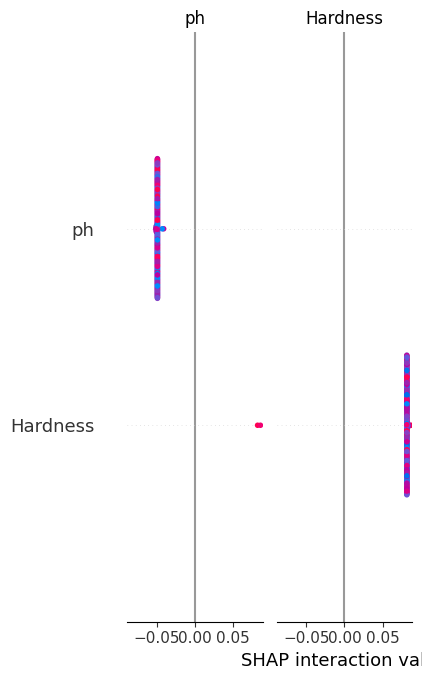

=== GradientBoosting ===
Variable Importance Plot - Global Interpretation


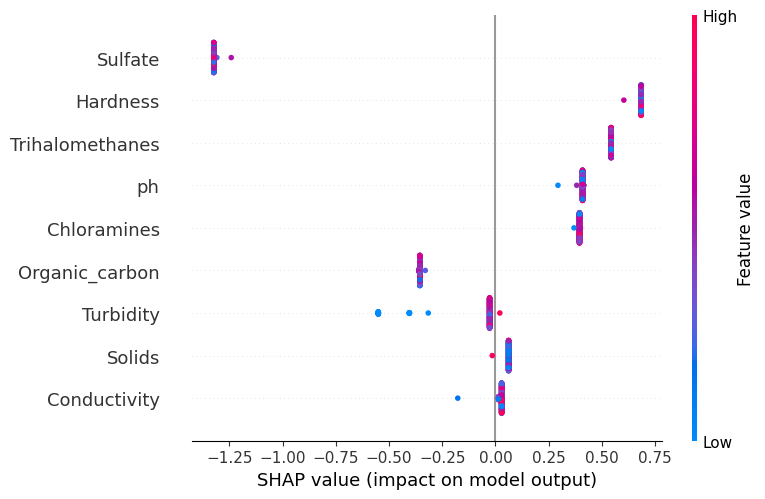

=== DecisionTree ===
Variable Importance Plot - Global Interpretation


<Figure size 640x480 with 0 Axes>

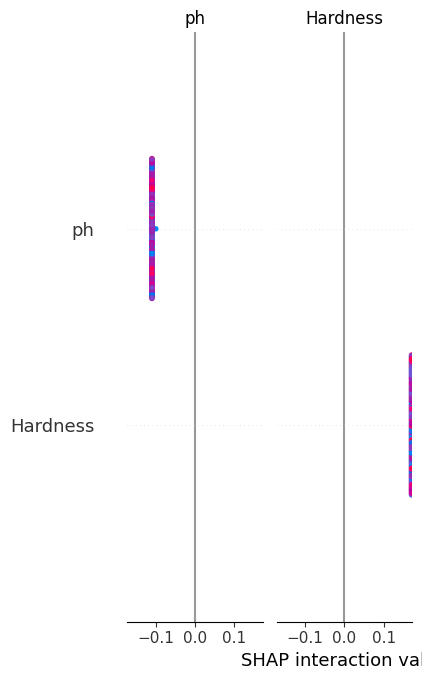

In [64]:
import shap
shap.initjs()



for name, model in models.items():
   
    if name != "LogReg" and name != "SVM" and name != "KNN" and name != "AdaBoost":
        print(f"=== {name} ===")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        print("Variable Importance Plot - Global Interpretation")
        figure = plt.figure()
        shap.summary_plot(shap_values, X_test)




=== LogReg ===
              precision    recall  f1-score   support

         0.0       0.65      0.50      0.57       400
         1.0       0.43      0.59      0.50       256

    accuracy                           0.54       656
   macro avg       0.54      0.54      0.53       656
weighted avg       0.57      0.54      0.54       656



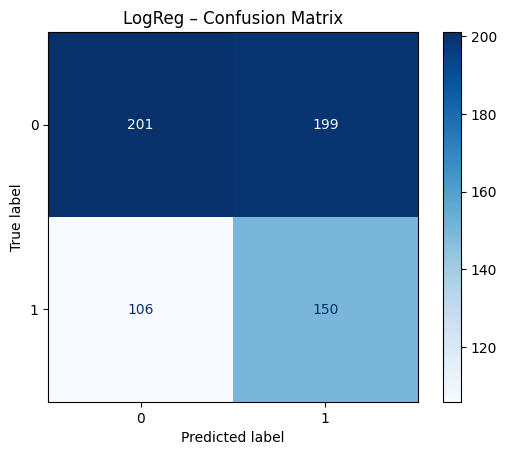

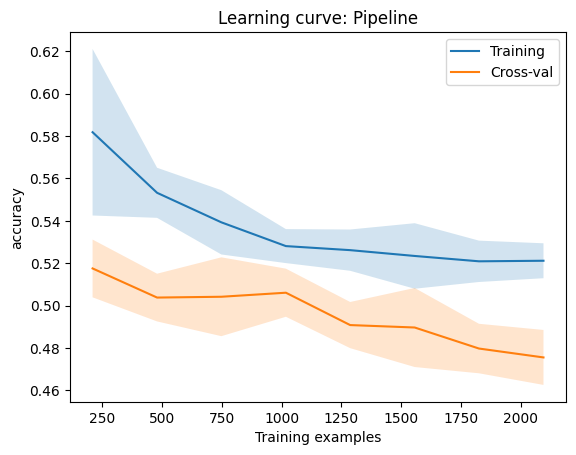


=== SVM ===
              precision    recall  f1-score   support

         0.0       0.69      0.69      0.69       400
         1.0       0.51      0.52      0.51       256

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.62      0.62       656



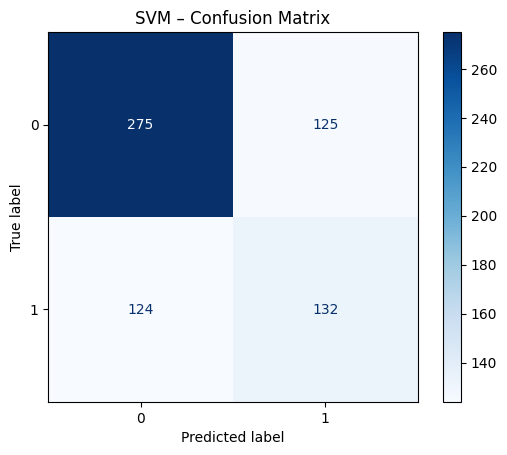

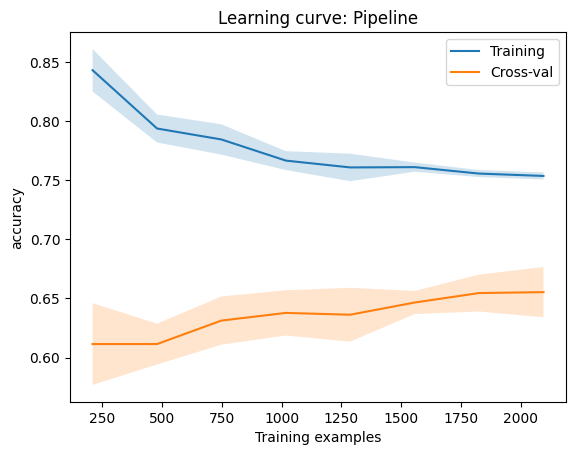


=== RandomForest ===
              precision    recall  f1-score   support

         0.0       0.67      0.82      0.74       400
         1.0       0.58      0.38      0.45       256

    accuracy                           0.65       656
   macro avg       0.63      0.60      0.60       656
weighted avg       0.64      0.65      0.63       656



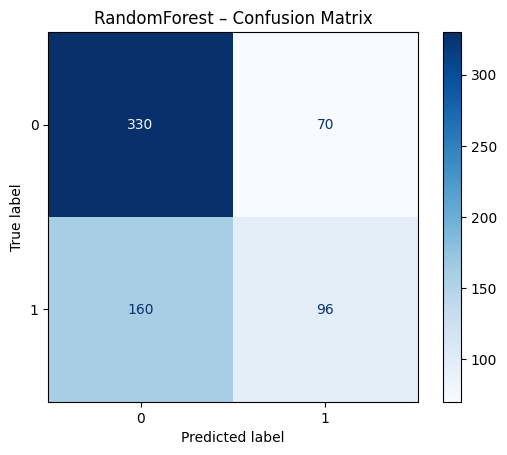

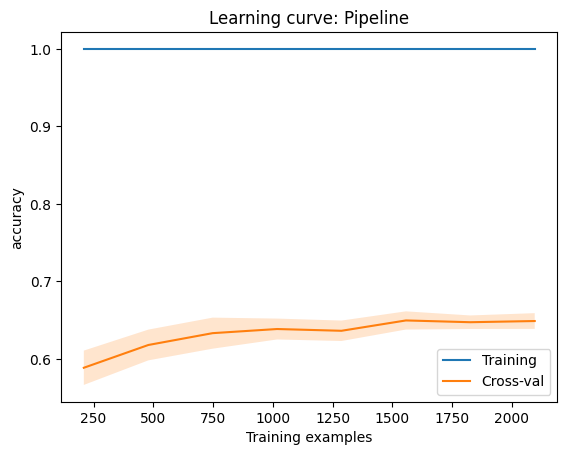


=== GradientBoosting ===
              precision    recall  f1-score   support

         0.0       0.68      0.69      0.68       400
         1.0       0.50      0.48      0.49       256

    accuracy                           0.61       656
   macro avg       0.59      0.59      0.59       656
weighted avg       0.61      0.61      0.61       656



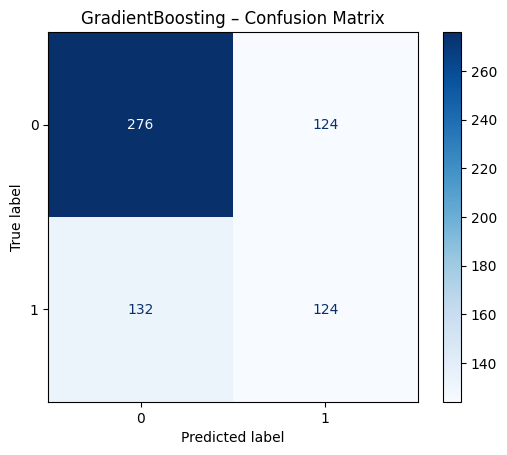

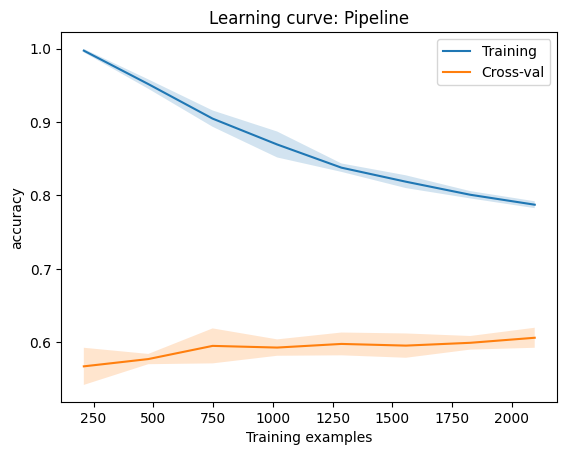


=== KNN ===
              precision    recall  f1-score   support

         0.0       0.65      0.64      0.64       400
         1.0       0.45      0.47      0.46       256

    accuracy                           0.57       656
   macro avg       0.55      0.55      0.55       656
weighted avg       0.57      0.57      0.57       656



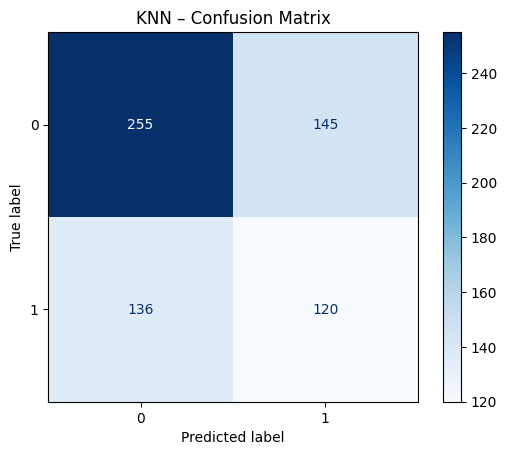

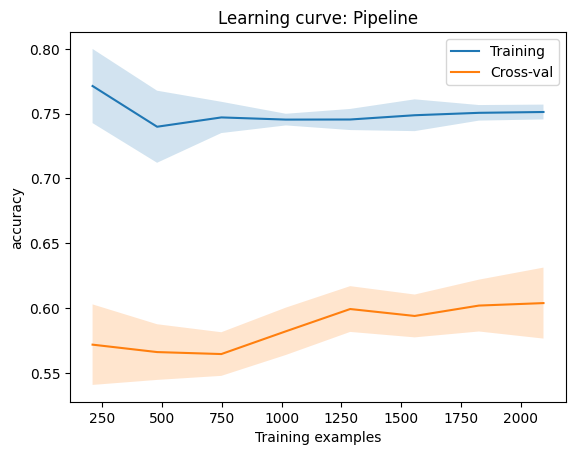


=== AdaBoost ===
              precision    recall  f1-score   support

         0.0       0.66      0.68      0.67       400
         1.0       0.47      0.45      0.46       256

    accuracy                           0.59       656
   macro avg       0.56      0.56      0.56       656
weighted avg       0.58      0.59      0.58       656



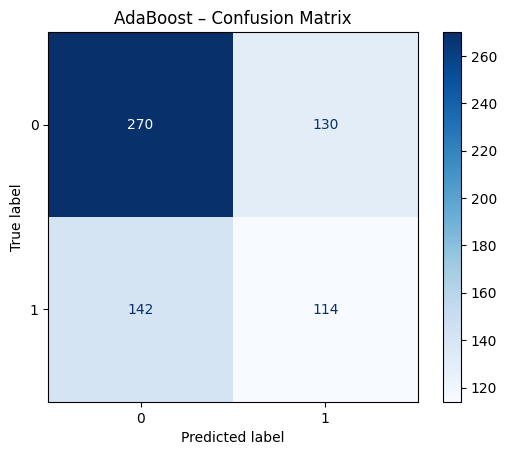

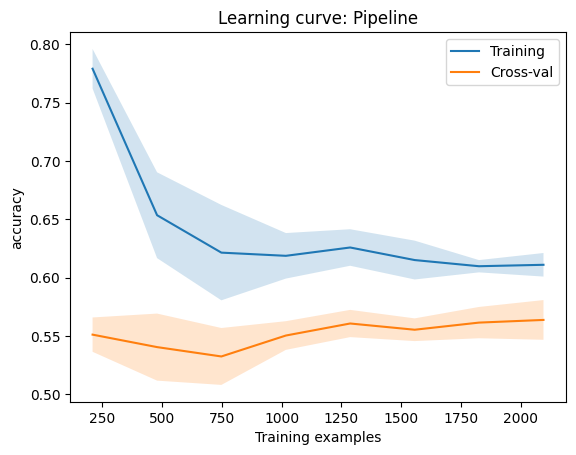


=== DecisionTree ===
              precision    recall  f1-score   support

         0.0       0.64      0.71      0.67       400
         1.0       0.45      0.38      0.41       256

    accuracy                           0.58       656
   macro avg       0.54      0.54      0.54       656
weighted avg       0.57      0.58      0.57       656



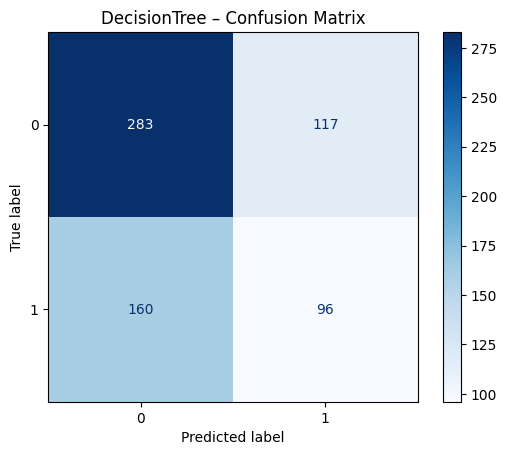

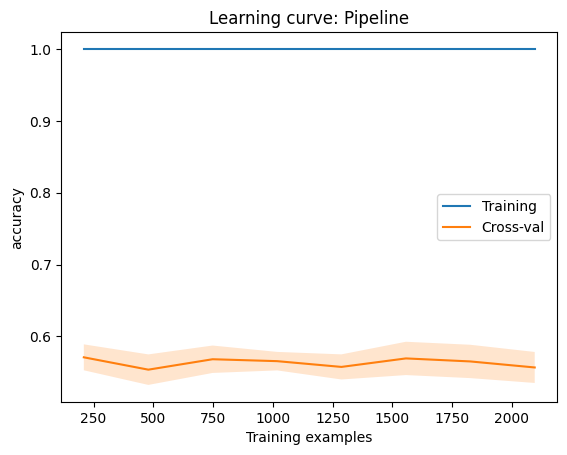

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.impute import KNNImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# columns = df.columns

# for col in columns:
#     percentile25 = df[col].quantile(0.25)
#     percentile75 = df[col].quantile(0.75)

#     iqr = percentile75 - percentile25

#     upper_limit = percentile75 + 1.5 * iqr
#     lower_limit = percentile25 - 1.5 * iqr

#     print("Upper limit", upper_limit)
#     print("Lower limit", lower_limit)

X = df2.drop("Potability", axis=1)
y = df2["Potability"]
#X = X.drop(columns=["index"])

# 80% temp, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


imputer = KNNImputer(n_neighbors=2)
sc = RobustScaler()


X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X_train_sc = sc.fit_transform(X_train_imp)
X_test_sc  = sc.transform(X_test_imp)

# df2 =  pd.DataFrame(
#     imputer.fit_transform(df),
#     columns=df.columns,
#     index=df.index
# )

X_train_sc_df = pd.DataFrame(
    X_train_sc,
    columns=X_train.columns,
    index=y_train.index
)

plt.figure(figsize=(12,8))
X_train_sc_df[features].plot(kind='box', subplots=True, sharey=False, figsize=(15, 5))
plt.tight_layout()
plt.show()



train_df = pd.concat([X_train_sc_df, y_train], axis=1)

# upsampling
df_majority = train_df[train_df.Potability == 0]
df_minority = train_df[train_df.Potability == 1]

# Upsample minority class to match majority class size
df_minority_upsampled = resample(df_minority, 
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority),    # to match majority class size
                                 random_state=123) # reproducible results

# Combine majority class with upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

X_train_up = df_upsampled.drop("Potability", axis=1)
y_train_up = df_upsampled["Potability"]



models = {
    "LogReg": LogisticRegression(max_iter=10000, solver="sag"),
    "SVM":  SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN":  KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
}



for name, model in models.items():
    model.fit(X_train_up, y_train_up)

    # TEST
    test_pred = model.predict(X_test_sc)
  
    print(f"\n=== {name} ===")

    print("Test report:")
    print(classification_report(y_test, test_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.show()

    # Learning curve 
    plot_learning_curve(model, X_train_up, y_train_up, scoring="accuracy")

In [68]:

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for name, model in models.items():
    cross_val_results = cross_val_score(model, X, y, cv=kf)
    print(f"\nCross-Validation Results (Accuracy) === {name} ===")
    for i, result in enumerate(cross_val_results, 1):
            print(f"  Fold {i}: {result * 100:.2f}%")
    print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')




 


Cross-Validation Results (Accuracy) === LogReg ===
  Fold 1: 62.80%
  Fold 2: 61.98%
  Fold 3: 59.24%
  Fold 4: 61.83%
  Fold 5: 58.93%
Mean Accuracy: 60.96%

Cross-Validation Results (Accuracy) === SVM ===
  Fold 1: 62.80%
  Fold 2: 61.98%
  Fold 3: 59.24%
  Fold 4: 61.98%
  Fold 5: 58.93%
Mean Accuracy: 60.99%

Cross-Validation Results (Accuracy) === RandomForest ===
  Fold 1: 68.29%
  Fold 2: 66.72%
  Fold 3: 66.26%
  Fold 4: 64.27%
  Fold 5: 65.95%
Mean Accuracy: 66.30%

Cross-Validation Results (Accuracy) === GradientBoosting ===
  Fold 1: 66.31%
  Fold 2: 66.56%
  Fold 3: 63.97%
  Fold 4: 62.90%
  Fold 5: 64.89%
Mean Accuracy: 64.93%

Cross-Validation Results (Accuracy) === KNN ===
  Fold 1: 53.05%
  Fold 2: 57.40%
  Fold 3: 57.56%
  Fold 4: 54.66%
  Fold 5: 54.66%
Mean Accuracy: 55.46%

Cross-Validation Results (Accuracy) === AdaBoost ===
  Fold 1: 63.72%
  Fold 2: 62.44%
  Fold 3: 61.07%
  Fold 4: 62.90%
  Fold 5: 60.31%
Mean Accuracy: 62.09%

Cross-Validation Results (Accurac

Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== RandomForest ===
Test report:
              precision    recall  f1-score   support

         0.0       0.65      0.91      0.76       400
         1.0       0.64      0.24      0.35       256

    accuracy                           0.65       656
   macro avg       0.64      0.58      0.55       656
weighted avg       0.65      0.65      0.60       656



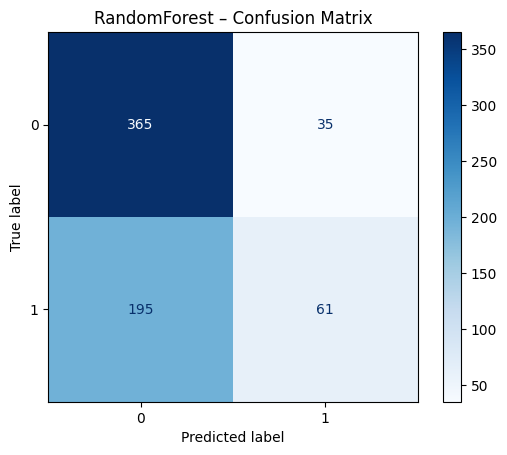

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_params = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 6, 8, 12, 16, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
}


dt_params = {
    "max_depth": [None, 4, 6, 8, 12, 16, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy", "log_loss"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=40,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    n_iter=40,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
models_cv = {
    "RandomForest": rf_search,
    "DecisionTree": dt_search,
}



for name, model in models_cv.items():
    model.fit(X_train_sc, y_train_up)

    # TEST
    test_pred = model.predict(X_test_sc)
  
    print(f"\n=== {name} ===")

    print("Test report:")
    print(classification_report(y_test, test_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.show()

    # Learning curve 
    plot_learning_curve(model, X_train_sc, y_train_up, scoring="accuracy")





=== RandomForest ===


C:\Users\Fiki\AppData\Local\Temp\ipykernel_36508\829718013.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_sc, feature_names=feat_names, plot_type="violin")


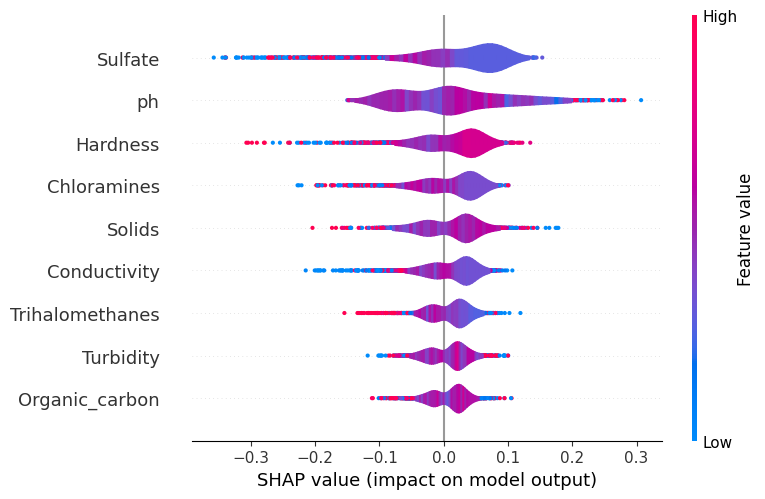

=== RandomForest ===


PermutationExplainer explainer: 101it [00:34,  2.08it/s]                         


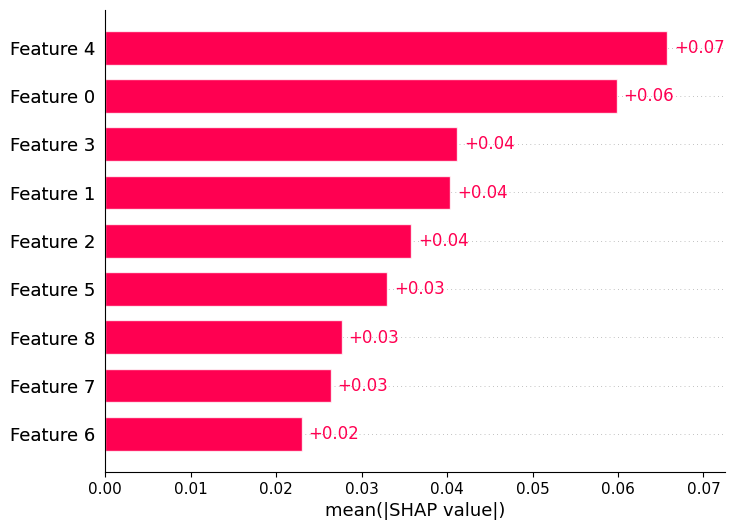

=== GradientBoosting ===


C:\Users\Fiki\AppData\Local\Temp\ipykernel_36508\829718013.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_sc, feature_names=feat_names, plot_type="violin")


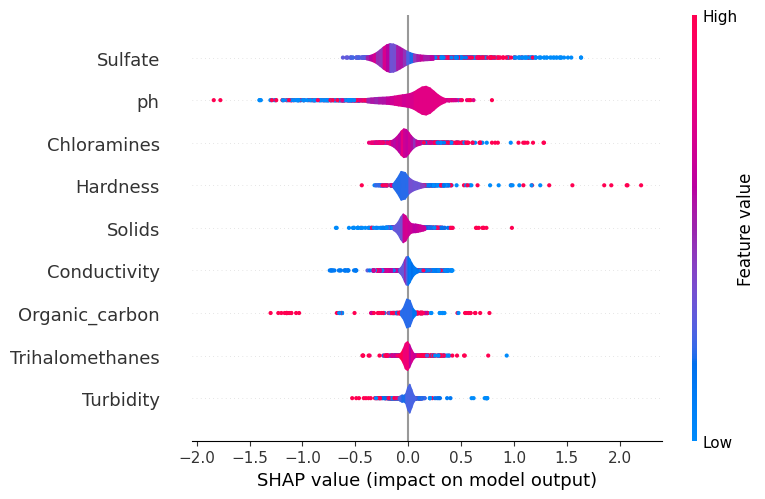

=== GradientBoosting ===


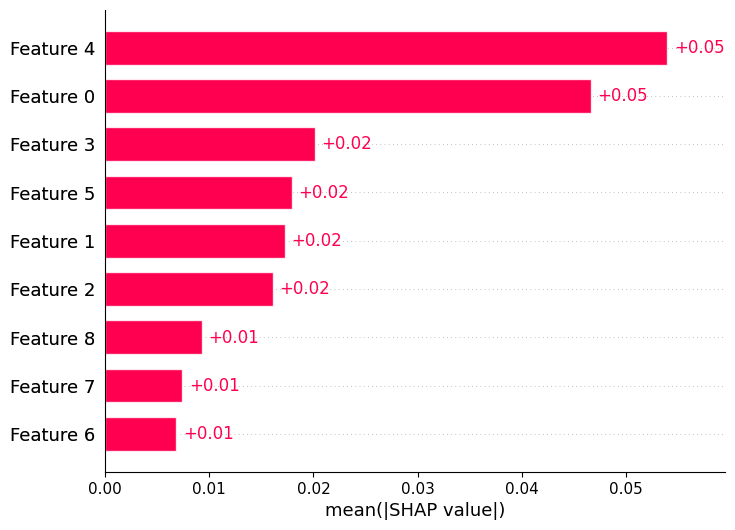

=== DecisionTree ===


C:\Users\Fiki\AppData\Local\Temp\ipykernel_36508\829718013.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_sc, feature_names=feat_names, plot_type="violin")


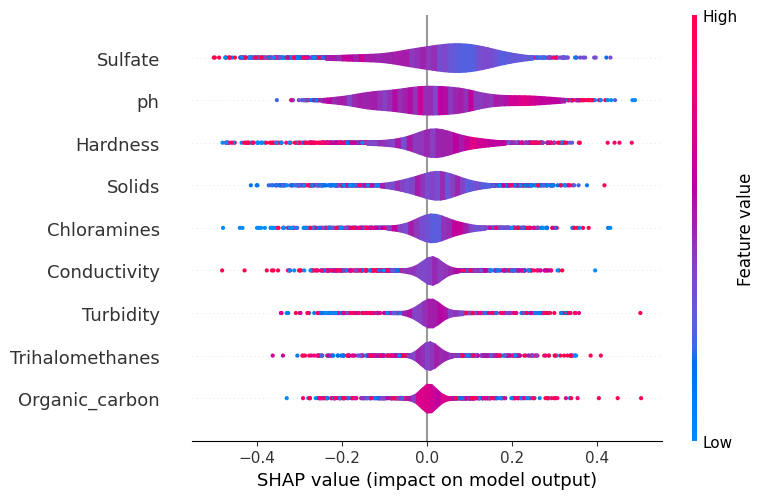

=== DecisionTree ===


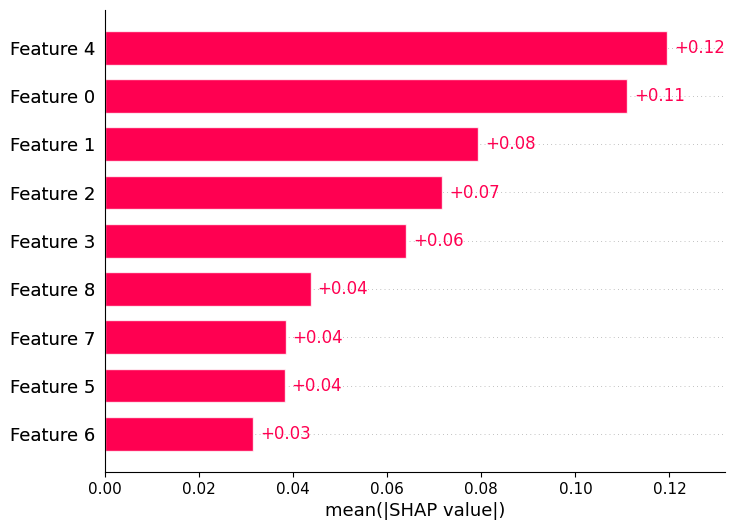

In [ ]:
def print_violin_shap(name, model):
        print(f"=== {name} ===")
        feat_names = list(X_train.columns) 
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train_sc)

        # Binary classification: shap_values may be [class0, class1]
        if isinstance(shap_values, list):
                shap_values = shap_values[1]

        shap_values = np.asarray(shap_values)

        # Ensure 2D: (n_samples, n_features)
        if shap_values.ndim == 3:
         # common cases
         if shap_values.shape[0] in (1, 2):      # (n_outputs, n_samples, n_features)
           shap_values = shap_values[0]
         elif shap_values.shape[2] in (1, 2):    # (n_samples, n_features, n_outputs)
           shap_values = shap_values[:, :, 0]
         else:
          raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

        shap.summary_plot(shap_values, X_train_sc, feature_names=feat_names, plot_type="violin")

def print_permutation_explainer_shap(name, model):
        print(f"=== {name} ===")
        explainer = shap.explainers.Permutation(model.predict_proba, X_train_sc)
        shap_values = explainer(X_train_sc[:100])
        shap_values = shap_values[..., 1]
        shap.plots.bar(shap_values)
        shap.plots.waterfall(shap_values[0])



print_violin_shap("RandomForest", models["RandomForest"])
print_permutation_explainer_shap("RandomForest", models["RandomForest"])

print_violin_shap("GradientBoosting", models["GradientBoosting"])
print_permutation_explainer_shap("GradientBoosting", models["GradientBoosting"])

print_violin_shap("DecisionTree", models["DecisionTree"])
print_permutation_explainer_shap("DecisionTree", models["DecisionTree"])

Original number of features: 9
Reduced number of features: 9


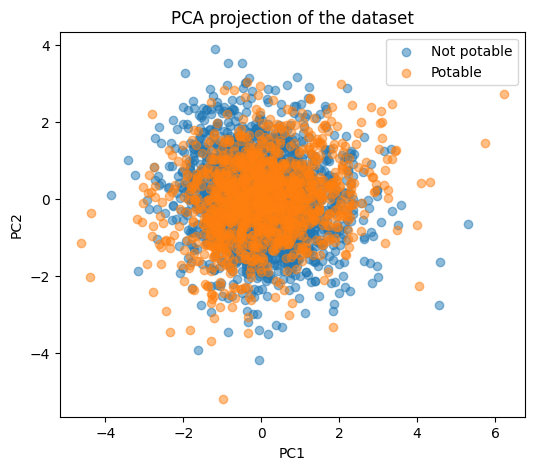

In [101]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_sc)

# Show results
print("Original number of features:", X_sc.shape[1])
print("Reduced number of features:", X_pca.shape[1])

plt.figure(figsize=(6,5))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], alpha=0.5, label="Not potable")
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], alpha=0.5, label="Potable")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA projection of the dataset")
plt.show()

In [ ]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(kernel="rbf", gamma=15, n_components=2)
X_kpca = kpca.fit_transform(X_sc)
print("Original number of features:", X_sc.shape[1])
print("Reduced number of features:", X_kpca.shape[1])

Original number of features: 9
Reduced number of features: 2
